В этой части модуля мы будем работать с популярным датасетом MovieLens, в котором собраны логи некоторой рекомендательной системы фильмов.

*Наши данные представляют собой четыре таблицы:*

```ratings1 и ratings2``` — таблицы с данными о выставленных пользователями оценках фильмов. Они имеют одинаковую структуру и типы данных — на самом деле это две части одной таблицы с оценками фильмов.

* userId — уникальный идентификатор пользователя, который выставил оценку;
* movieId — уникальный идентификатор фильма;
* rating — рейтинг фильма.

```dates``` — таблица с датами выставления всех оценок

* date — дата и время выставления оценки фильму.

```movies``` — таблица с информацией о фильмах

* movieId — уникальный идентификатор фильма;
* title — название фильма и год его выхода;
* genres — жанры фильма.

Нам надо получить единую таблицу, в которой будут собраны рейтинги, даты выставления рейтингов, а также информация о фильмах. Вот как мы будем действовать:

* 1
Склеим таблицы ```ratings1``` и ```ratings2``` в единую структуру.

* 2
К полученной таблице с рейтингами подсоединим столбец с датой проставления рейтинга, склеив столбцы таблиц между собой.

* 3
Присоединим к нашей таблице информацию о названиях и жанрах фильмов.

In [2]:
import pandas as pd

In [3]:
movies = pd.read_csv('data/movies.csv', sep=',')
display(movies['title'].value_counts().nunique)

<bound method IndexOpsMixin.nunique of title
Emma (1996)                                  2
Saturn 3 (1980)                              2
Confessions of a Dangerous Mind (2002)       2
Eros (2004)                                  2
War of the Worlds (2005)                     2
                                            ..
Black Butler: Book of the Atlantic (2017)    1
No Game No Life: Zero (2017)                 1
Flint (2017)                                 1
Bungo Stray Dogs: Dead Apple (2018)          1
Andrew Dice Clay: Dice Rules (1991)          1
Name: count, Length: 9737, dtype: int64>

In [4]:
ratings1 = pd.read_csv('data/ratings1.csv', sep=',')
display(ratings1['userId'].value_counts().nunique)

<bound method IndexOpsMixin.nunique of userId
68     1260
249    1046
182     977
177     904
232     862
       ... 
147      20
189      20
194      20
207      20
257      20
Name: count, Length: 274, dtype: int64>

In [5]:
ratings2 = pd.read_csv('data/ratings2.csv', sep=',')
display(ratings2)

,userId,movieId,rating
0,274,5621,2.0
1,274,5630,3.0
2,274,5667,3.5
3,274,5679,3.5
4,274,5690,3.0
...,...,...,...
60831,610,166534,4.0
60832,610,168248,5.0
60833,610,168250,5.0
60834,610,168252,5.0


In [6]:
dates = pd.read_csv('data/dates.csv', sep=',')
print(dates['date'].mode())

0    2016-04-04 16:39:58
Name: date, dtype: str


# Объединение DataFrame: concat

Первым делом мы должны склеить таблицы ```ratings1 и ratings2``` по строкам.

Для этого воспользуемся встроенной функцией Pandas ```concat()```, которая позволяет склеивать (конкатенировать) таблицы как по строкам, так и по столбцам.

## Основные параметры функции ```concat()```

* ```objs``` — список объектов DataFrame ([df1, df2,…]), которые должны быть сконкатенированы;
* ```axis``` — ось определяет направление конкатенации: 0 — конкатенация по строкам (по умолчанию), 1 — конкатенация по столбцам;
* ```join``` — либо ```inner``` (пересечение), либо ```outer``` (объединение); рассмотрим этот момент немного позже;
* ```ignore_index``` — по умолчанию установлено значение False, которое позволяет значениям индекса оставаться такими, какими они были в исходных данных. Если установлено значение True, параметр будет игнорировать исходные значения и повторно назначать значения индекса в последовательном порядке.

** Для корректной конкатенации по строкам объединяемые таблицы должны иметь одинаковую структуру — идентичное число и имена столбцов. ** 

*Примечание. Обратите внимание, что concat является функцией библиотеки, а не методом DataFrame. Поэтому её вызов осуществляется как ```pd.concat(...).```*

In [7]:
ratings1 = pd.read_csv('data/ratings1.csv', sep=',')
display(ratings1)

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
...,...,...,...
39996,274,5582,2.5
39997,274,5585,3.5
39998,274,5588,3.5
39999,274,5618,4.0


In [8]:
ratings2 = pd.read_csv('data/ratings2.csv', sep=',')
display(ratings2)

,userId,movieId,rating
0,274,5621,2.0
1,274,5630,3.0
2,274,5667,3.5
3,274,5679,3.5
4,274,5690,3.0
...,...,...,...
60831,610,166534,4.0
60832,610,168248,5.0
60833,610,168250,5.0
60834,610,168252,5.0


In [9]:
ratings = pd.concat([ratings1, ratings2])
display(ratings)

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
...,...,...,...
60831,610,166534,4.0
60832,610,168248,5.0
60833,610,168250,5.0
60834,610,168252,5.0


В результате мы увеличили первую таблицу, добавив снизу строки второй таблицы

На первый взгляд может показаться, что всё прошло успешно, однако если мы посмотрим на индексы последних строк таблицы, то увидим, что их нумерация не совпадает с количеством строк. Это может привести к некорректному объединению таблиц по ключевым столбцам на следующем этапе решения нашей задачи.

Это связано с тем, что по умолчанию concat сохраняет первоначальные индексы объединяемых таблиц, а обе наши таблицы индексировались, начиная от 0. Чтобы создать новые индексы, нужно выставить параметр ignore_index на True:

In [10]:
ratings = pd.concat(
    [ratings1, ratings2],
    ignore_index=True
)
display(ratings)

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
...,...,...,...
100832,610,166534,4.0
100833,610,168248,5.0
100834,610,168250,5.0
100835,610,168252,5.0


Казалось бы, совсем другое дело! Но это ещё не всё. Давайте узнаем количество строк в таблицах ratings и dates, ведь нам предстоит вертикально склеить их между собой:

In [11]:
print('Число строк в таблице ratings: ', ratings.shape[0])
print('Число строк в таблице dates: ', dates.shape[0])
print(ratings.shape[0] == dates.shape[0])

Число строк в таблице ratings:  100837
Число строк в таблице dates:  100836
False


Размерность таблиц разная — как такое могло произойти?

На самом деле очень просто: при выгрузке данных информация об оценках какого-то  пользователя попала в обе таблицы (ratings1 и ratings2). В результате конкатенации случилось дублирование строк. В данном примере их легко найти — выведем последнюю строку таблицы ratings1 и первую строку таблицы ratings2:

In [12]:
display(ratings1.tail(1))
display(ratings2.head(1))

,userId,movieId,rating
40000,274,5621,2.0


,userId,movieId,rating
0,274,5621,2.0


Чтобы очистить таблицу от дублей, мы можем воспользоваться методом DataFrame ```drop_duplicates()```, который удаляет повторяющиеся строки в таблице. Не забываем обновить индексы после удаления дублей, выставив параметр ```ignore_index``` в методе ```drop_duplicates()``` на значение ```True```:

In [13]:
ratings = ratings.drop_duplicates(ignore_index=True)
print('Число строк в таблице ratings: ', ratings.shape[0])

Число строк в таблице ratings:  100836


Наконец, мы можем добавить к нашей таблице с оценками даты их выставления. Для этого конкатенируем таблицы ratings и dates по столбцам:

In [14]:
ratings_dates = pd.concat([ratings, dates], axis=1)
display(ratings_dates.tail(7))

,userId,movieId,rating,date
100829,610,164179,5.0,2017-05-03 21:07:11
100830,610,166528,4.0,2017-05-04 06:29:25
100831,610,166534,4.0,2017-05-03 21:53:22
100832,610,168248,5.0,2017-05-03 22:21:31
100833,610,168250,5.0,2017-05-08 19:50:47
100834,610,168252,5.0,2017-05-03 21:19:12
100835,610,170875,3.0,2017-05-03 21:20:15


***Задание 6.3 (External resource)***

В ваше распоряжение предоставлена директория users ('./Root/users'). В данной директории содержатся csv-файлы, в каждом из которых хранится информация об идентификаторах пользователей (user_id) и ссылках на их фотографии (image_url). Количество файлов в директории может быть любым.

Вам необходимо написать функцию concat_user_files(path), параметром которой является path — путь до директории.

Функция должна:

Объединить информацию из всех csv-файлов в единый DataFrame.

Удалить дубликаты.

Обновить индексы результирующей таблицы.

Отсортировать пользователей по числовой части user_id (игнорируя буквенную часть).

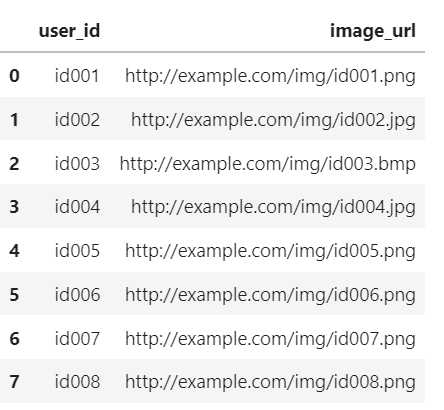

In [ ]:
def concat_user_files(path):
    
    link = path + '/user_id.csv'
    user_id = pd.read_csv(link, sep=',')
    image_url = pd.read_csv('https://example.com/img/image_url.csv')
    
    concat_user_f = pd.concat(
    [user_id, image_url],
    ignore_index=True
)
    
    concat_user_f = concat_user_f.drop_duplicates(ignore_index=True)
    
    concat_user_f.sort_values(by='user_id')
    
    return concat_user_f

path = './Root/users'
concat_user_files(path)

хер пойми какое эталонное решение. в жизнь бы не решил

In [ ]:
import pandas as pd
import os
def concat_user_files(path):
    data = pd.DataFrame()
    file_names = os.listdir(path)
    file_names.sort()
    for file in file_names:
        tmp_data = pd.read_csv(path + '/' + file)
        data = pd.concat([data, tmp_data], axis=0, ignore_index=True)
    data = data.drop_duplicates()
    return data     

У таблиц ratings и movies есть общий столбец movieId, который каждому фильму из таблицы movies ставит в соответствие поставленные ему оценки из таблицы ratings. Мы хотим объединить их в единую структуру согласно этому соответствию. Объединения такого рода часто называют объединением по ключевому столбцу.

## Типы объединений

Типы объединений в Pandas тесно связаны с операцией ```join``` из SQL, которую мы будем рассматривать в курсе в дальнейшем.

Они представлены на схеме ниже в виде кругов Эйлера. 

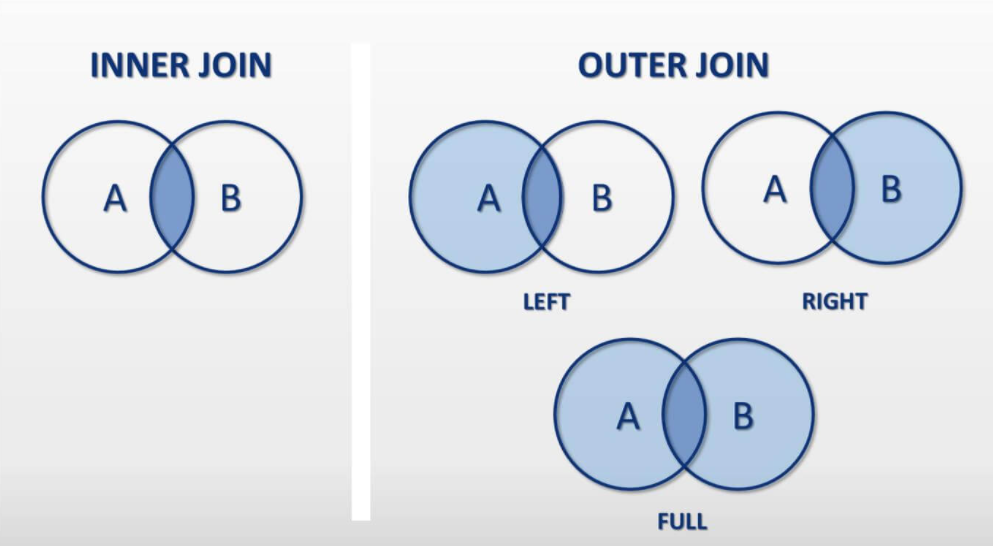

***Два основных типа объединения таблиц:***

*inner* (внутреннее)

При использовании такого типа объединения в результирующей таблице остаются только те записи, которые есть в обеих таблицах.

Аналогия в теории множеств - Пересечение (intersection) множеств А и В.
Строки, для которых совпадение не было найдено, удаляются.

*outer* (внешнее)

Данный тип делится на три подтипа:

```full``` — используется как outer по умолчанию, объединяет все варианты в обеих таблицах.
Аналогия в теории множеств -  Объединение (union) множеств А и В.

```left``` — для всех записей из «левой» таблицы (например, ratings) ведётся поиск соответствий в «правой» (например, movies). В результирующей таблице останутся только те значения, которым были найдены соответствия, то есть только значения из ratings.
Аналогия в теории множеств - 
Вычитание (difference) множества B из результата объединения (union) множеств А и В.

```right``` — аналогично предыдущему, но остаются значения только из «правой» таблицы. 

Аналогия в теории множеств - 
Вычитание (difference) множества А из результата объединения (union) множеств А и В.

## Метод объединения join

Для объединения двух таблиц по индексам используется метод DataFrame join(). Однако данный метод можно применить и для того, чтобы объединить таблицы по ключевому столбцу (в нашем случае это movieId).

### Основные параметры метода join()

* ```other``` — таблица, которую мы присоединяем. При объединении она является «правой», а исходная таблица, от имени которой вызывается метод, является «левой».
* ```how``` — параметр типа объединения. Он может принимать значения 'inner', 'left' (left outer), 'right' (right outer), и 'outer' (full outer). По умолчанию параметр установлен на 'left'.
* ```on``` — параметр, который определяет, по какому столбцу в «левой» таблице происходит объединение по индексам из «правой».
* ```lsuffix``` и ```rsuffix``` — дополнения (суффиксы) к названиям одноимённых столбцов в «левой» и «правой» таблицах.

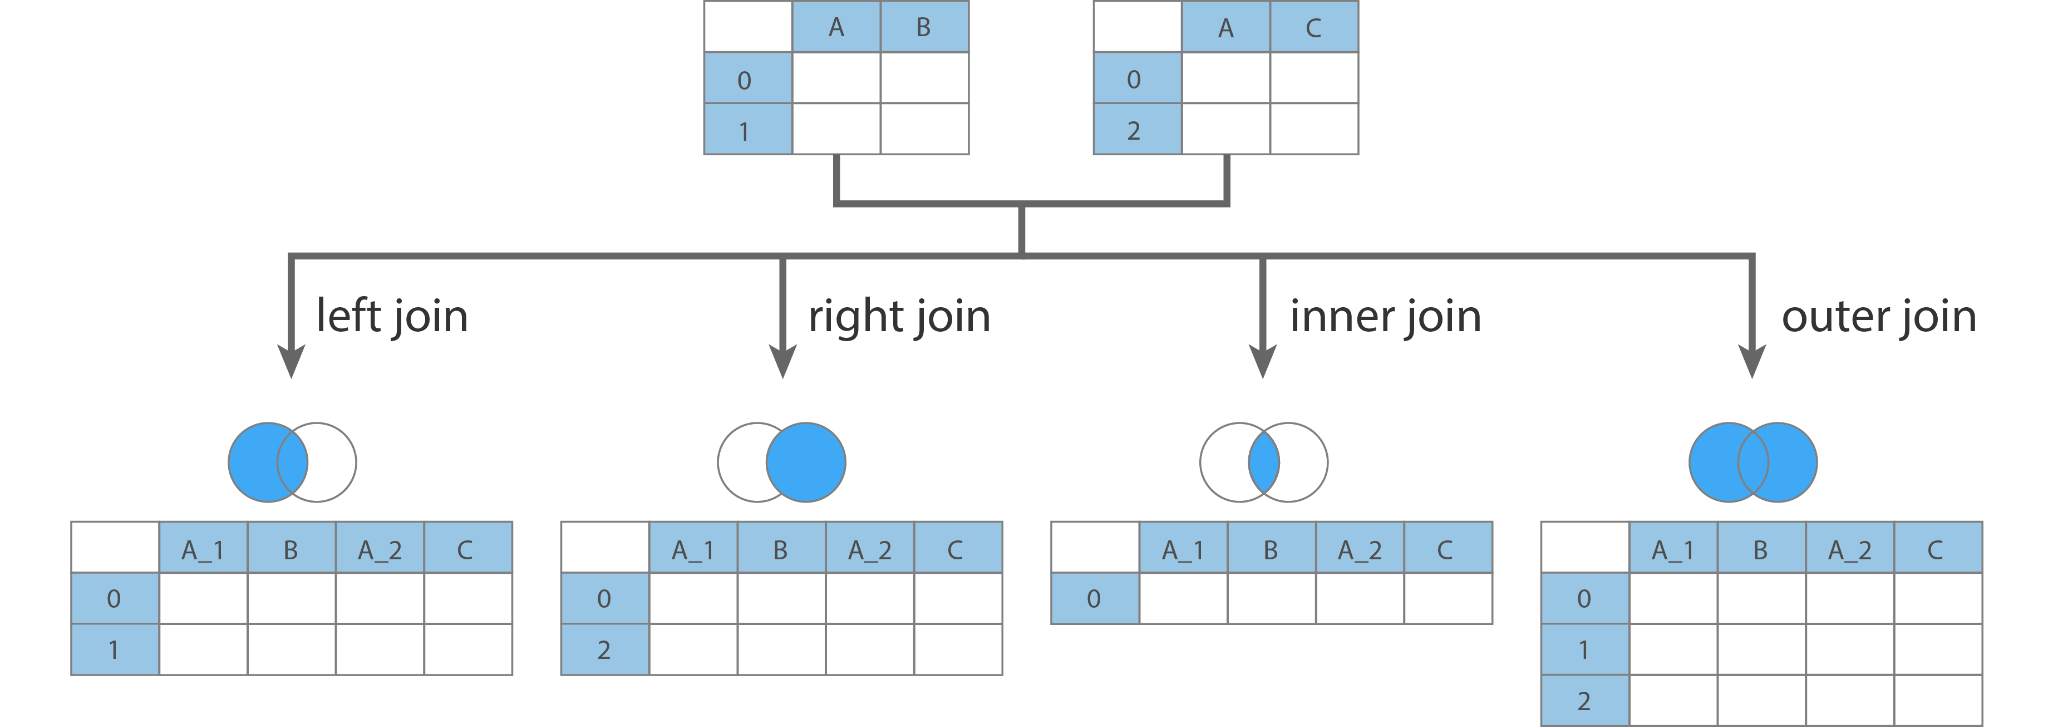

Если использовать метод join() «в лоб» (без указания ключевого столбца), то объединение произойдёт, как и задумано — по индексам двух таблиц согласно установленному типу объединения.

Проверим это, объединив таблицы типом left. Так как в наших таблицах есть одноимённые столбцы, установим один из суффиксов, чтобы избежать ошибки:

In [16]:
joined_false = ratings_dates.join(
    movies,
    rsuffix='_right',
    how='left'
)
display(joined_false)

,userId,movieId,rating,date,movieId_right,title,genres
0,1,1,4.0,2000-07-30 18:45:03,1.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,2000-07-30 18:20:47,2.0,Jumanji (1995),Adventure|Children|Fantasy
2,1,6,4.0,2000-07-30 18:37:04,3.0,Grumpier Old Men (1995),Comedy|Romance
3,1,47,5.0,2000-07-30 19:03:35,4.0,Waiting to Exhale (1995),Comedy|Drama|Romance
4,1,50,5.0,2000-07-30 18:48:51,5.0,Father of the Bride Part II (1995),Comedy
...,...,...,...,...,...,...,...
100831,610,166534,4.0,2017-05-03 21:53:22,NaN,NaN,NaN
100832,610,168248,5.0,2017-05-03 22:21:31,NaN,NaN,NaN
100833,610,168250,5.0,2017-05-08 19:50:47,NaN,NaN,NaN
100834,610,168252,5.0,2017-05-03 21:19:12,NaN,NaN,NaN


In [17]:
joined_false = ratings_dates.join(
    movies,
    rsuffix='_right',
    how='right'
)
display(joined_false)

,userId,movieId,rating,date,movieId_right,title,genres
0,1,1,4.0,2000-07-30 18:45:03,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,2000-07-30 18:20:47,2,Jumanji (1995),Adventure|Children|Fantasy
2,1,6,4.0,2000-07-30 18:37:04,3,Grumpier Old Men (1995),Comedy|Romance
3,1,47,5.0,2000-07-30 19:03:35,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,1,50,5.0,2000-07-30 18:48:51,5,Father of the Bride Part II (1995),Comedy
...,...,...,...,...,...,...,...
9737,64,3481,4.0,2006-10-22 12:37:45,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,64,3489,3.0,2006-10-22 23:28:09,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,64,3499,4.5,2006-10-22 23:26:41,193585,Flint (2017),Drama
9740,64,3510,3.0,2006-10-22 23:27:26,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


Однако это не тот результат, который мы хотели, ведь мы не получили соответствия фильмов и их рейтингов. Чтобы совместить таблицы по ключевому столбцу с помощью метода join(), **необходимо использовать ключевой столбец в «правой» таблице в качестве индекса**. Это можно сделать с помощью метода ```set_index()```. Также необходимо указать название ключа в параметре ```on```.

In [18]:
joined = ratings_dates.join(
    movies.set_index('movieId'),
    on='movieId',
    how='left'
)
display(joined.head())

,userId,movieId,rating,date,title,genres
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


В результате такого объединения для каждого идентификатора фильма movieId в таблице ratings_dates найден совпадающий с ним идентификатор movieId в таблице movies и присоединена информация о самом фильме (title и genres). Это как раз то, что нам нужно.

Обратите внимание, что в результате такого объединения остался лишь один столбец movieId.

Примечание. ```Join()``` также можно использовать с параметром ```how='outer'```.

## Метод объединения merge


Аналогично предыдущему, метод ```merge()``` предназначен для слияния двух таблиц по ключевым столбцам или по индексам. Однако, в отличие от ```join()```, метод ```merge()``` предлагает более гибкий способ управления объединением, благодаря чему является более популярным.

### Основные параметры метода merge()

* ```right``` — присоединяемая таблица. По умолчанию она является «правой».
* ```how``` — параметр типа объединения. По умолчанию принимает значение 'inner'.
* ```on``` — параметр, который определяет, по какому столбцу происходит объединение. Определяется автоматически, но рекомендуется указывать вручную.
* ```left_on``` — если названия столбцов в «левой» и «правой» таблицах не совпадают, то данный параметр отвечает за наименования ключевого столбца исходной таблицы.
* ```right_on``` — аналогично предыдущему, параметр отвечает за наименование ключевого столбца присоединяемой таблицы.

Метод merge() в первую очередь предназначен для слияния таблиц по заданным ключам, поэтому он не требует установки ключевых столбцов в качестве индекса присоединяемой таблицы. Кроме того, данный метод позволяет объединять даже таблицы с разноимёнными ключами. Таким образом, merge() проще в использовании и более многофункционален, чем схожие методы.

In [19]:
merged = ratings_dates.merge(
    movies,
    on='movieId',
    how='left'
)
display(merged.head())

,userId,movieId,rating,date,title,genres
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [20]:
print('Число строк в таблице ratings_dates: ', ratings_dates.shape[0])
print('Число строк в таблице merged: ', merged.shape[0])
print(ratings_dates.shape[0] == merged.shape[0])

Число строк в таблице ratings_dates:  100836
Число строк в таблице merged:  100836
True


## Особенности использования ```merge()```

Возникает вопрос: почему мы выбрали тип объединения left, а не full, например?

Найти ответ нам поможет пример. Объединим ratings_dates с movies по ключевому столбцу movieId, но с параметром ```how='outer' (full outer)``` и выведем размер таблицы, а также её «хвост»:

In [21]:
merged2 = ratings_dates.merge(
    movies,
    on='movieId',
    how='outer'
)
print('Число строк в таблице merged2: ', merged2.shape[0])
display(merged2.tail())

# Число строк в таблице merged: 100854

Число строк в таблице merged2:  100854


,userId,movieId,rating,date,title,genres
100849,184.0,193581,4.0,2018-09-16 14:44:42,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
100850,184.0,193583,3.5,2018-09-16 14:52:25,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
100851,184.0,193585,3.5,2018-09-16 14:56:45,Flint (2017),Drama
100852,184.0,193587,3.5,2018-09-16 15:00:21,Bungo Stray Dogs: Dead Apple (2018),Action|Animation
100853,331.0,193609,4.0,2018-09-17 04:13:26,Andrew Dice Clay: Dice Rules (1991),Comedy


Результирующее число строк в таблице увеличилось. Но за счёт чего?

Оказывается, в таблице movies содержались фильмы, которым ещё не были выставлены оценки. В результате объединения типом full outer информация о фильмах перенеслась из таблицы movies в результирующую таблицу. Однако, поскольку оценки фильмам ещё не были выставлены, соответствующие столбцы таблицы ratings_dates заполнились пропусками (NaN). Такие фильмы были записаны в конец таблицы.

Метод ```merge()``` с внешним (outer) типом объединения может использоваться как аналог метода ```concat()``` при объединении таблиц с одинаковой структурой (одинаковые количество и названия столбцов) по строкам. В таком случае все одноимённые столбцы таблиц будут считаться ключевыми.

Рассмотрим пример: объединим таблицы ratings1 и ratings2, как мы уже делали раньше, но теперь используем метод ```merge()```:

In [22]:
merge_ratings = ratings1.merge(ratings2, how='outer')
print('Число строк в таблице merge_ratings: ', merge_ratings.shape[0])
display(merge_ratings)
# Число строк в таблице merge_ratings: 100836

Число строк в таблице merge_ratings:  100836


,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
...,...,...,...
100831,610,166534,4.0
100832,610,168248,5.0
100833,610,168250,5.0
100834,610,168252,5.0


Обратите внимание, что при использовании метода merge() для склейки двух таблиц у нас автоматически пропали дубликаты, которые мы видели при использовании метода concat(). Это особенность метода merge() — автоматическое удаление дублей.

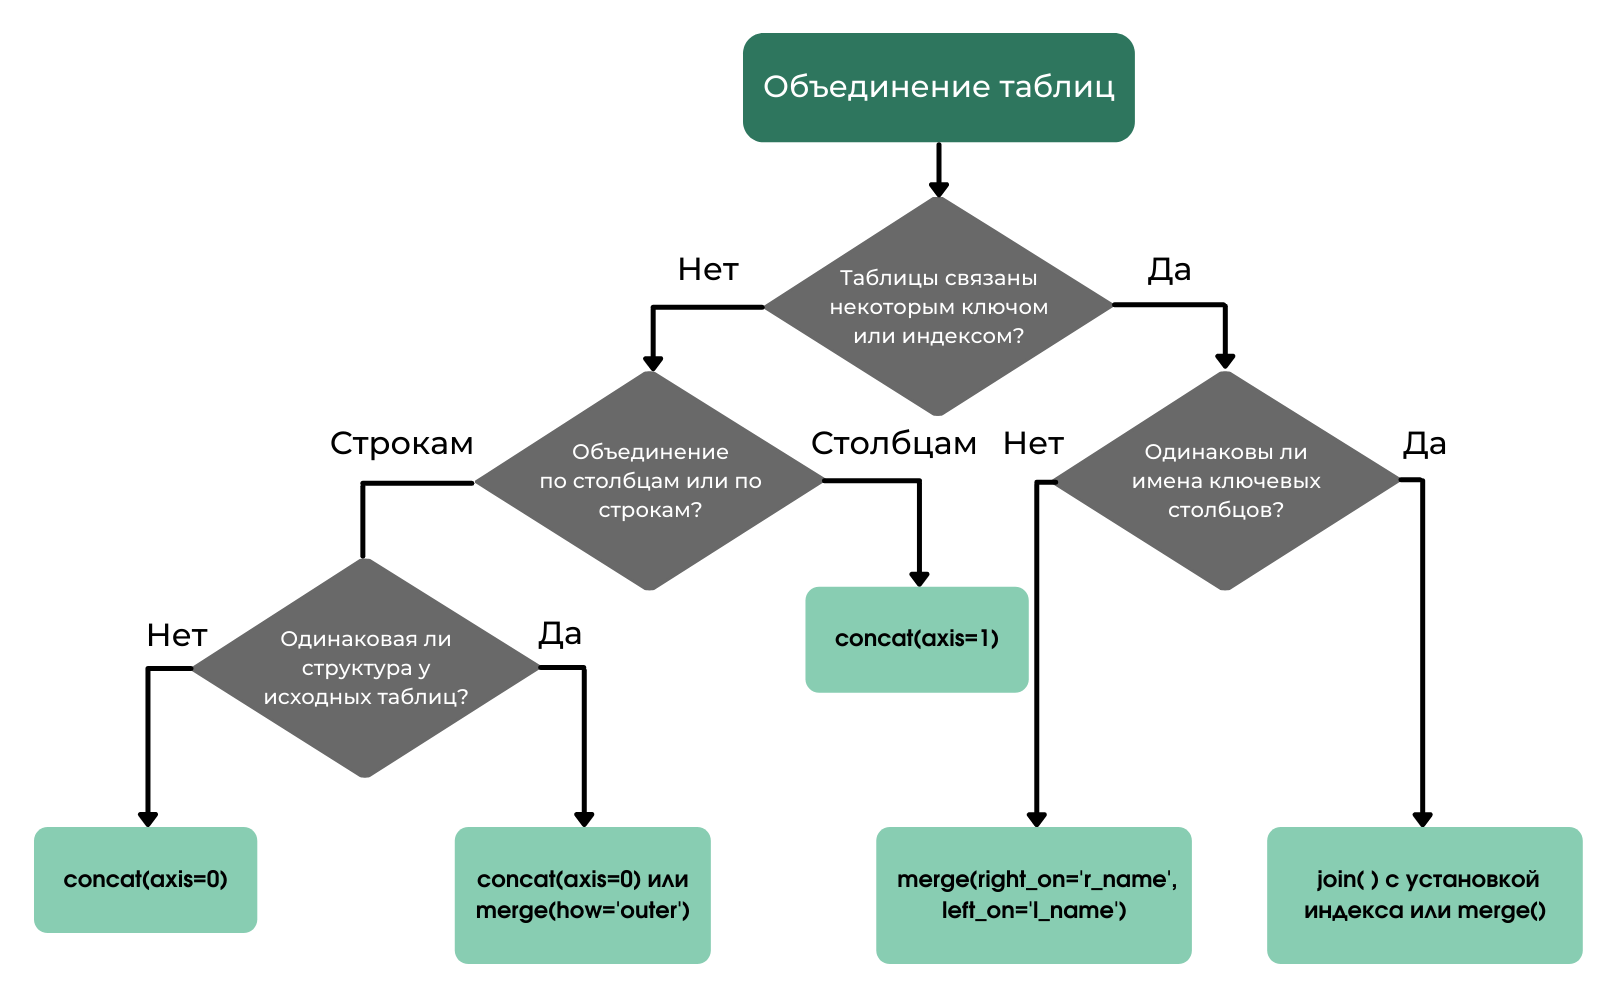

Задание 7.4

Даны две исходные таблицы:

In [29]:
a = pd.DataFrame({'A': ['a', 'b', 'c'], 'B': [103, 214, 124], 'C': [1, 4, 2]})
b = pd.DataFrame({'V': ['d', 'b', 'c'], 'U': [1393.7, 9382.2, 1904.5], 'C': [1, 3, 2]})
display(a)
display(b)

,A,B,C
0,a,103,1
1,b,214,4
2,c,124,2


,V,U,C
0,d,1393.7,1
1,b,9382.2,3
2,c,1904.5,2


In [33]:
a.merge(b, how='inner', on='C')

,A,B,C,V,U
0,a,103,1,d,1393.7
1,c,124,2,c,1904.5


Задание 7.5 (External resource)

Даны две таблицы: items_df, в которой содержится информация о наличии товаров на складе, и purchase_df с данными о покупках товаров.

Первая:

In [35]:
items_df = pd.DataFrame({
    'item_id': [417283, 849734, 132223, 573943, 19475, 3294095, 382043, 302948, 100132, 312394],
    'vendor': ['Samsung', 'LG', 'Apple', 'Apple', 'LG', 'Apple', 'Samsung', 'Samsung', 'LG', 'ZTE'],
    'stock_count': [54, 33, 122, 18, 102, 43, 77, 143, 60, 19]
})
display(items_df)

,item_id,vendor,stock_count
0,417283,Samsung,54
1,849734,LG,33
2,132223,Apple,122
3,573943,Apple,18
4,19475,LG,102
5,3294095,Apple,43
6,382043,Samsung,77
7,302948,Samsung,143
8,100132,LG,60
9,312394,ZTE,19


In [36]:
purchase_df = pd.DataFrame({
    'purchase_id': [101, 101, 101, 112, 121, 145, 145, 145, 145, 221],
    'item_id': [417283, 849734, 132223, 573943, 19475, 3294095, 382043, 302948, 103845, 100132],
    'price': [13900, 5330, 38200, 49990, 9890, 33000, 67500, 34500, 89900, 11400]
})
display(purchase_df)

,purchase_id,item_id,price
0,101,417283,13900
1,101,849734,5330
2,101,132223,38200
3,112,573943,49990
4,121,19475,9890
5,145,3294095,33000
6,145,382043,67500
7,145,302948,34500
8,145,103845,89900
9,221,100132,11400


Информация в таблицах представлена в виде следующих столбцов:

* item_id — идентификатор модели;
* vendor — производитель модели;
* stock_count — имеющееся на складе количество данных моделей (в штуках);
* purchase_id — идентификатор покупки;
* price — стоимость модели в покупке.

Вам необходимо сделать следующее:

Сформируйте DataFrame merged, так чтобы после объединения purchase_df и items_df остались модели, которые учтены на складе и имели продажи.

На основе таблицы merged найдите суммарную выручку, которую можно было бы получить от продажи всех товаров, имеющихся на складе. Результат занесите в переменную income.

In [42]:
merged = items_df.merge(
    purchase_df,
    on='item_id',
    how='left'
)

display(merged)

,item_id,vendor,stock_count,purchase_id,price
0,417283,Samsung,54,101.0,13900.0
1,849734,LG,33,101.0,5330.0
2,132223,Apple,122,101.0,38200.0
3,573943,Apple,18,112.0,49990.0
4,19475,LG,102,121.0,9890.0
5,3294095,Apple,43,145.0,33000.0
6,382043,Samsung,77,145.0,67500.0
7,302948,Samsung,143,145.0,34500.0
8,100132,LG,60,221.0,11400.0
9,312394,ZTE,19,NaN,NaN


In [46]:
import numpy as np
merged['purchase_id'] = merged['purchase_id'].replace(np.nan, 0)
merged['price'] = merged['price'].replace(np.nan, 0)
display(merged)

,item_id,vendor,stock_count,purchase_id,price
0,417283,Samsung,54,101.0,13900.0
1,849734,LG,33,101.0,5330.0
2,132223,Apple,122,101.0,38200.0
3,573943,Apple,18,112.0,49990.0
4,19475,LG,102,121.0,9890.0
5,3294095,Apple,43,145.0,33000.0
6,382043,Samsung,77,145.0,67500.0
7,302948,Samsung,143,145.0,34500.0
8,100132,LG,60,221.0,11400.0
9,312394,ZTE,19,0.0,0.0


In [47]:
income = sum(merged['stock_count'] * merged['price'])
print(income)

19729490.0


Эталонное решение

In [50]:
merged = items_df.merge(purchase_df, how='inner', on='item_id')
income = (merged['price'] * merged['stock_count']).sum()
display(merged)
print(income)

,item_id,vendor,stock_count,purchase_id,price
0,417283,Samsung,54,101,13900
1,849734,LG,33,101,5330
2,132223,Apple,122,101,38200
3,573943,Apple,18,112,49990
4,19475,LG,102,121,9890
5,3294095,Apple,43,145,33000
6,382043,Samsung,77,145,67500
7,302948,Samsung,143,145,34500
8,100132,LG,60,221,11400


19729490


--------------